Training Data Analysis


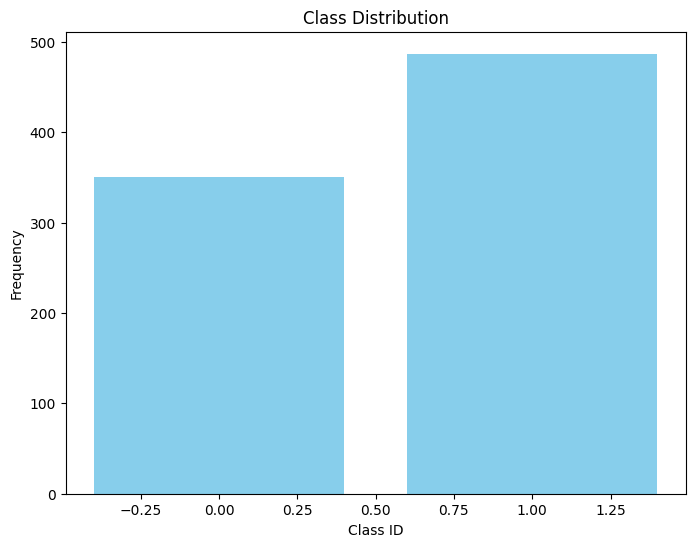

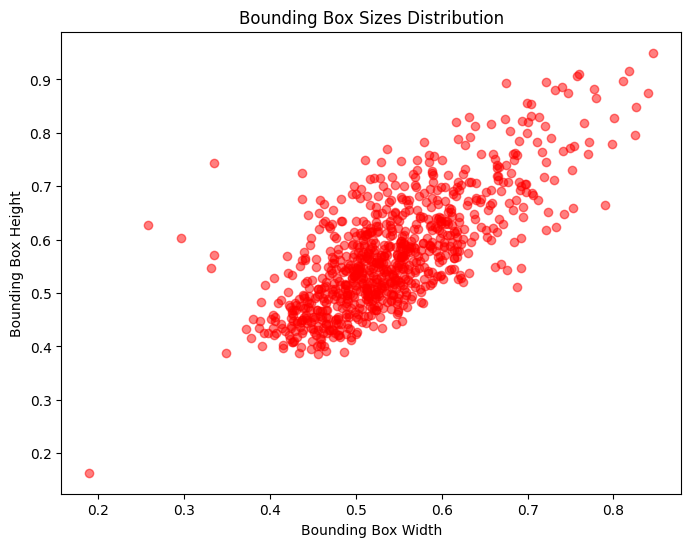

Validation Data Analysis


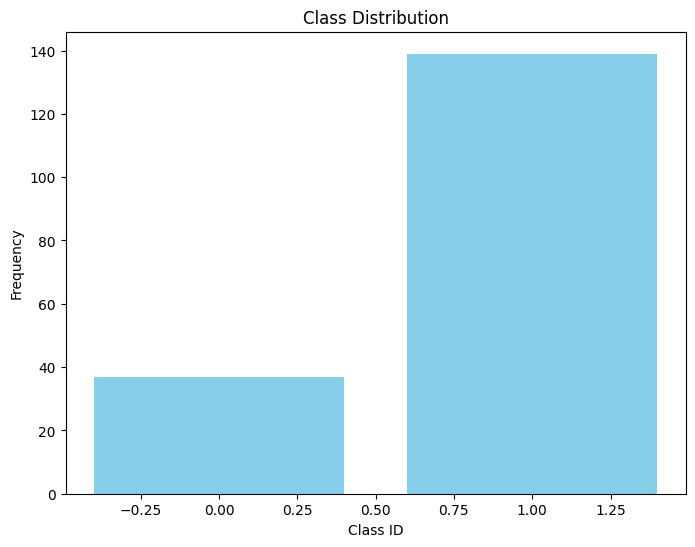

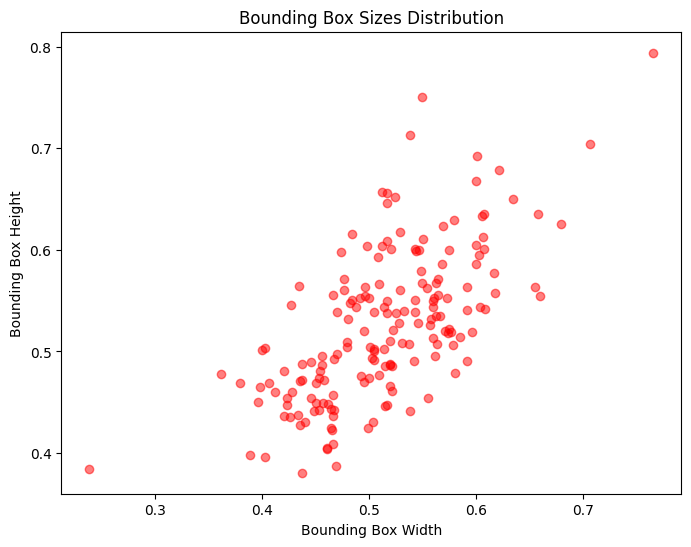

In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define paths to image and label directories
train_images_dir = r"Y:\2024-2025\NEW DEV\OCT\TK198249-A Hybrid Deep Learning Framework for Deep fake Detection Using Temporal and Spatial Features\BACKEND\image\fake.v1i.yolov8\train\images"
valid_images_dir =r"Y:\2024-2025\NEW DEV\OCT\TK198249-A Hybrid Deep Learning Framework for Deep fake Detection Using Temporal and Spatial Features\BACKEND\image\fake.v1i.yolov8\valid\images"
train_labels_dir = r"Y:\2024-2025\NEW DEV\OCT\TK198249-A Hybrid Deep Learning Framework for Deep fake Detection Using Temporal and Spatial Features\BACKEND\image\fake.v1i.yolov8\train\labels"
valid_labels_dir = r"Y:\2024-2025\NEW DEV\OCT\TK198249-A Hybrid Deep Learning Framework for Deep fake Detection Using Temporal and Spatial Features\BACKEND\image\fake.v1i.yolov8\valid\labels"

# Function to read label files and extract data
def extract_label_data(label_dir):
    class_counts = {}
    bbox_sizes = []

    for label_file in os.listdir(label_dir):
        if label_file.endswith('.txt'):
            label_path = os.path.join(label_dir, label_file)
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])

                    # Count the number of occurrences of each class
                    if class_id not in class_counts:
                        class_counts[class_id] = 0
                    class_counts[class_id] += 1

                    # Store the bounding box sizes for further analysis
                    bbox_sizes.append((width, height))
    
    return class_counts, bbox_sizes

# Function to plot class distribution and bounding box sizes
def plot_data_analysis(class_counts, bbox_sizes):
    # Plot class distribution
    plt.figure(figsize=(8, 6))
    plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
    plt.xlabel('Class ID')
    plt.ylabel('Frequency')
    plt.title('Class Distribution')
    plt.show()

    # Plot bounding box width and height distribution
    widths, heights = zip(*bbox_sizes)
    plt.figure(figsize=(8, 6))
    plt.scatter(widths, heights, color='red', alpha=0.5)
    plt.xlabel('Bounding Box Width')
    plt.ylabel('Bounding Box Height')
    plt.title('Bounding Box Sizes Distribution')
    plt.show()

# Analyze training and validation data
train_class_counts, train_bbox_sizes = extract_label_data(train_labels_dir)
valid_class_counts, valid_bbox_sizes = extract_label_data(valid_labels_dir)

# Plot the analysis for training data
print("Training Data Analysis")
plot_data_analysis(train_class_counts, train_bbox_sizes)

# Plot the analysis for validation data
print("Validation Data Analysis")
plot_data_analysis(valid_class_counts, valid_bbox_sizes)


Displaying a random image from training data with bounding boxes:


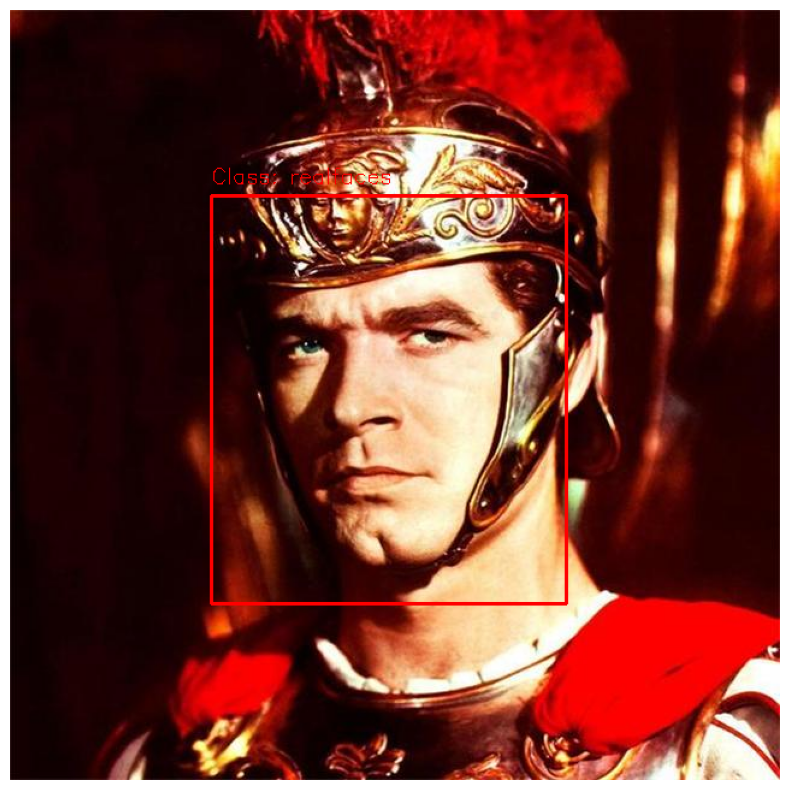

Displaying a random image from validation data with bounding boxes:


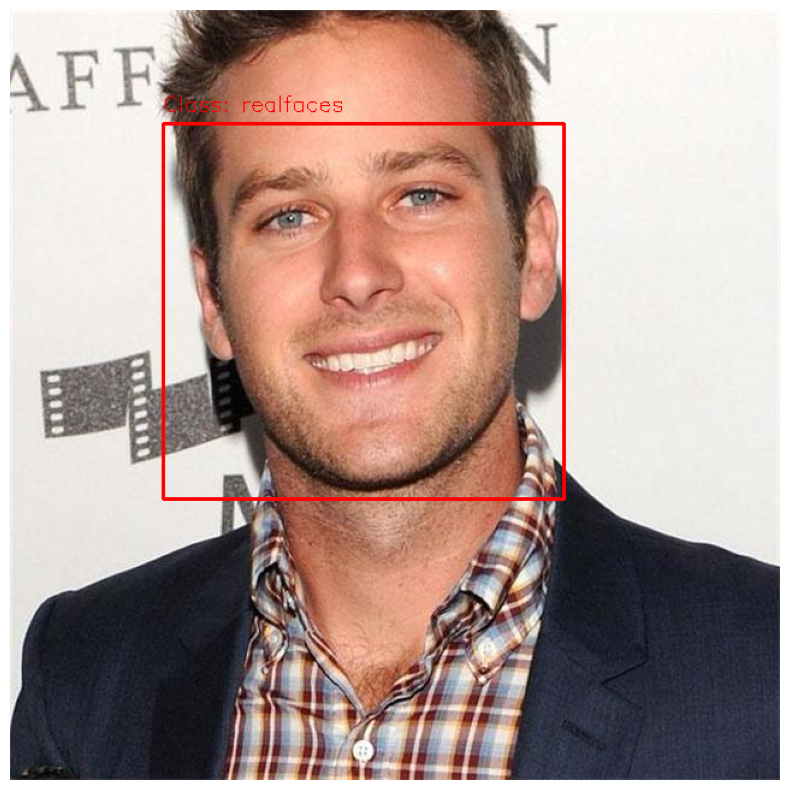

In [10]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt


# Class names
class_names = ['fakefaces', 'realfaces']

# Function to read label files and extract data
def extract_label_data(label_dir):
    label_data = {}

    for label_file in os.listdir(label_dir):
        if label_file.endswith('.txt'):
            label_path = os.path.join(label_dir, label_file)
            with open(label_path, 'r') as f:
                labels = []
                for line in f:
                    parts = line.strip().split()
                    class_id = int(parts[0])  # Get class ID
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])

                    # Map class ID to class name
                    class_name = class_names[class_id]

                    labels.append((class_name, x_center, y_center, width, height))
                label_data[label_file] = labels
    
    return label_data

# Function to display a random image and its bounding boxes
def display_random_image_with_bbox(image_dir, label_data):
    # Select a random image
    image_file = random.choice(os.listdir(image_dir))
    image_path = os.path.join(image_dir, image_file)
    image = cv2.imread(image_path)
    
    # Read corresponding label file
    label_file = image_file.replace('.jpg', '.txt')  # Assuming image is in .jpg format and label in .txt
    labels = label_data.get(label_file, [])
    
    # Convert BGR image to RGB for displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Plot image
    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    
    # Plot bounding boxes
    for label in labels:
        class_name, x_center, y_center, width, height = label
        # Convert YOLO format to pixel coordinates
        img_height, img_width, _ = image.shape
        x_min = int((x_center - width / 2) * img_width)
        y_min = int((y_center - height / 2) * img_height)
        x_max = int((x_center + width / 2) * img_width)
        y_max = int((y_center + height / 2) * img_height)

        # Draw the bounding box
        color = (255, 0, 0)  # Blue color for the bounding box
        thickness = 2
        cv2.rectangle(image_rgb, (x_min, y_min), (x_max, y_max), color, thickness)
        
        # Optionally, you can label the boxes with class names
        label_text = f"Class: {class_name}"
        cv2.putText(image_rgb, label_text, (x_min, y_min-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 1)
    
    # Show the image with bounding boxes
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()

# Extract labels from training data
train_label_data = extract_label_data(train_labels_dir)

# Display random images with bounding boxes from training data
print("Displaying a random image from training data with bounding boxes:")
display_random_image_with_bbox(train_images_dir, train_label_data)

# Optionally, you can repeat the same for validation data if needed
valid_label_data = extract_label_data(valid_labels_dir)
print("Displaying a random image from validation data with bounding boxes:")
display_random_image_with_bbox(valid_images_dir, valid_label_data)


Found 'fakefaces' in -_20221117142721_png.rf.b3f3b36a73842f1285712c5a16896c5a.txt: fakefaces (ID: 0)
Found 'fakefaces' in -_20221117142734_png.rf.fb287a80bfb232214c97098f2d0ef65d.txt: fakefaces (ID: 0)
Found 'fakefaces' in -_20221117142745_png.rf.9d1e0f3eb5c38e5df2babaf1f59d1006.txt: fakefaces (ID: 0)
Found 'fakefaces' in -_20221117142754_png.rf.da278a4fb8cd21848fc49c6b34e8823c.txt: fakefaces (ID: 0)
Found 'fakefaces' in -_20221117142823_png.rf.72c5011f7c407c82b9b21f8fde1f1036.txt: fakefaces (ID: 0)
Found 'fakefaces' in -_20221117143007_png.rf.f8b02ed5a3f85b842f8d11382ae8613d.txt: fakefaces (ID: 0)
Found 'fakefaces' in -_20221117143014_png.rf.568c81e808594ecd40c6b97ca89367d2.txt: fakefaces (ID: 0)
Found 'fakefaces' in -_20221117143036_png.rf.0ebed052de71972f6c533caea1f84b49.txt: fakefaces (ID: 0)
Found 'fakefaces' in -_20221117143058_png.rf.2fe120d480b37ba469813522515ea135.txt: fakefaces (ID: 0)
Found 'fakefaces' in -_20221117143111_png.rf.888f64e0ac457a0eae08c31f61492792.txt: fakeface

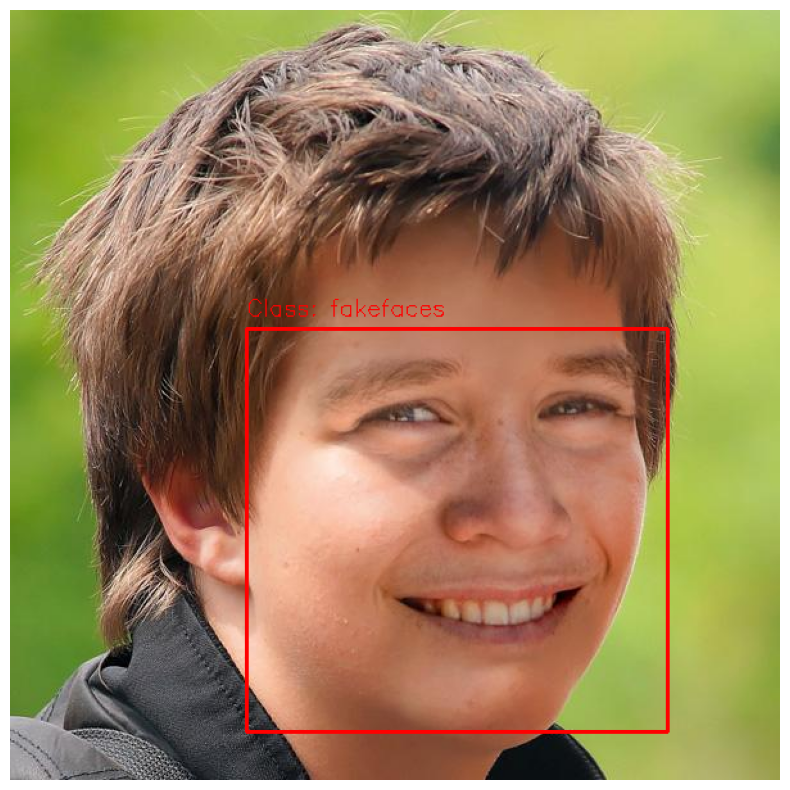

Found 'fakefaces' in -_20221117142611_png.rf.d1b0f96bcb91f57bff2e8bb28a301ef7.txt: fakefaces (ID: 0)
Found 'fakefaces' in -_20221117142804_png.rf.048740aeec362634dd5001170c7d8fbc.txt: fakefaces (ID: 0)
Found 'fakefaces' in -_20221117143023_png.rf.cf9fe4a4f44ef572f4a18b3c31dd2fee.txt: fakefaces (ID: 0)
Found 'fakefaces' in -_20221117143349_png.rf.fcde033f4215baa814d00079ba215e78.txt: fakefaces (ID: 0)
Found 'fakefaces' in -_20221117143420_png.rf.3b3556b780ab764dc69fe59d65d9bff7.txt: fakefaces (ID: 0)
Found 'fakefaces' in -_20221117143455_png.rf.146b6f1d49af21d578e225093e46d48c.txt: fakefaces (ID: 0)
Found 'fakefaces' in -_20221117143824_png.rf.28b75e9dc6c20d97149948557a021122.txt: fakefaces (ID: 0)
Found 'fakefaces' in easy_fake_074_jpg.rf.91615d11b5c548754ba7e4ccaf58beb5.txt: fakefaces (ID: 0)
Found 'fakefaces' in easy_fake_085_jpg.rf.44a9a8ca9d1e16e9c4f2092cf108ae3f.txt: fakefaces (ID: 0)
Found 'fakefaces' in easy_fake_092_jpg.rf.48f9336ba94d5e7b72e0e79addcbefaa.txt: fakefaces (ID: 0)

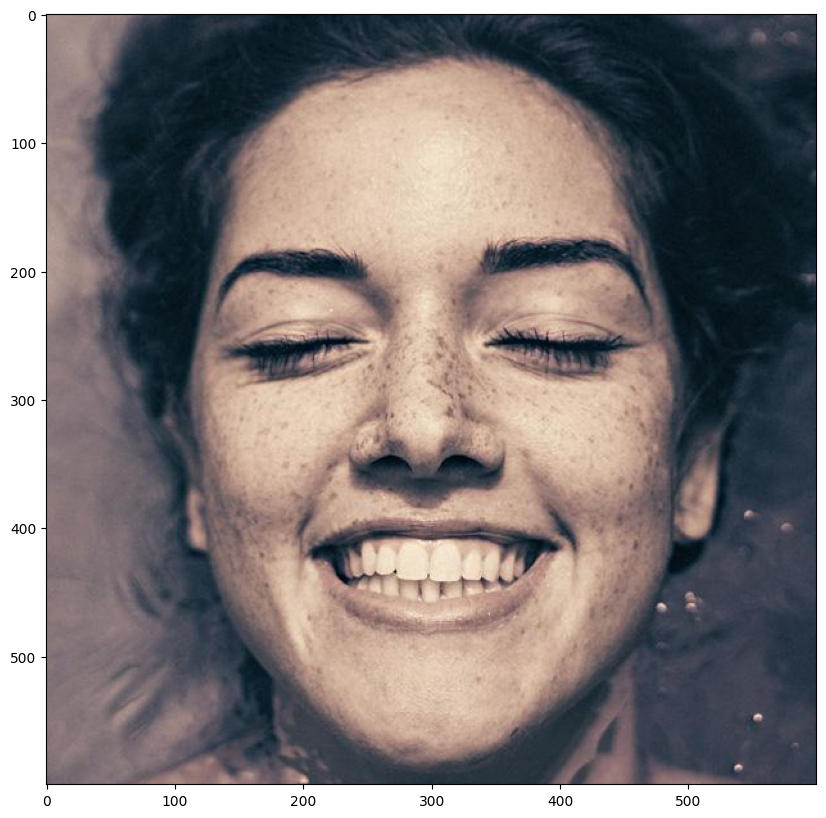

In [15]:
# Class names
class_names = ['fakefaces', 'realfaces']

# Function to read label files and extract data
def extract_label_data(label_dir):
    label_data = {}

    for label_file in os.listdir(label_dir):
        if label_file.endswith('.txt'):
            label_path = os.path.join(label_dir, label_file)
            with open(label_path, 'r') as f:
                labels = []
                for line in f:
                    parts = line.strip().split()
                    class_id = int(parts[0])  # Get class ID
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])

                    # Map class ID to class name
                    class_name = class_names[class_id]

                    # Debugging: Check if 'fakefaces' class is present in the labels
                    if class_name == 'fakefaces':
                        print(f"Found 'fakefaces' in {label_file}: {class_name} (ID: {class_id})")

                    labels.append((class_name, x_center, y_center, width, height))
                label_data[label_file] = labels
    
    return label_data

# Function to display a random image and its bounding boxes for 'fakefaces' only
def display_random_fakefaces(image_dir, label_data):
    # Select a random image
    image_file = random.choice(os.listdir(image_dir))
    image_path = os.path.join(image_dir, image_file)
    image = cv2.imread(image_path)
    
    # Read corresponding label file
    label_file = image_file.replace('.jpg', '.txt')  # Assuming image is in .jpg format and label in .txt
    labels = label_data.get(label_file, [])
    
    if not labels:
        print(f"No labels found for {image_file}")
    
    # Convert BGR image to RGB for displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Plot image
    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    
    # Plot bounding boxes for only 'fakefaces' class
    fakefaces_found = False  # To track if fakefaces are found in this image
    for label in labels:
        class_name, x_center, y_center, width, height = label
        if class_name == 'fakefaces':  # Only plot bounding boxes for 'fakefaces'
            fakefaces_found = True
            # Convert YOLO format to pixel coordinates
            img_height, img_width, _ = image.shape
            x_min = int((x_center - width / 2) * img_width)
            y_min = int((y_center - height / 2) * img_height)
            x_max = int((x_center + width / 2) * img_width)
            y_max = int((y_center + height / 2) * img_height)

            # Draw the bounding box
            color = (255, 0, 0)  # Blue color for the bounding box
            thickness = 2
            cv2.rectangle(image_rgb, (x_min, y_min), (x_max, y_max), color, thickness)
            
            # Optionally, you can label the boxes with class names
            label_text = f"Class: {class_name}"
            cv2.putText(image_rgb, label_text, (x_min, y_min-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 1)
    
    if fakefaces_found:
        plt.imshow(image_rgb)
        plt.axis('off')
        plt.show()
    else:
        print(f"No 'fakefaces' found in {image_file}")

# Extract labels from training data
train_label_data = extract_label_data(train_labels_dir)

# Display random images with 'fakefaces' class bounding boxes from training data
print("Displaying a random image from training data with 'fakefaces' bounding boxes:")
display_random_fakefaces(train_images_dir, train_label_data)

# Optionally, you can repeat the same for validation data if needed
valid_label_data = extract_label_data(valid_labels_dir)
print("Displaying a random image from validation data with 'fakefaces' bounding boxes:")
display_random_fakefaces(valid_images_dir, valid_label_data)

In [1]:
def create_requirements_txt():
    # Define the packages and their versions
    packages = {
        'ultralytics': '8.3.174',
        'ultralytics-thop': '2.0.15',
        'numpy': '1.26.4',
        'matplotlib': '3.7.2',
        'opencv-python': '4.11.0.86',
        'pillow': '11.2.1',
        'pyyaml': '6.0.2',
        'requests': '2.32.4',
        'scipy': '1.15.3',
        'torch': '2.6.0+cu124',
        'torchvision': '0.21.0+cu124',
        'tqdm': '4.67.1',
        'psutil': '7.0.0',
        'py-cpuinfo': '9.0.0',
        'pandas': '2.2.3',
        'nvidia-cublas-cu12': '12.4.5.8',
        'nvidia-cuda-cupti-cu12': '12.4.127',
        'nvidia-cuda-nvrtc-cu12': '12.4.127',
        'nvidia-cuda-runtime-cu12': '12.4.127',
        'nvidia-cudnn-cu12': '9.1.0.70',
        'nvidia-cufft-cu12': '11.2.1.3',
        'nvidia-curand-cu12': '10.3.5.147',
        'nvidia-cusolver-cu12': '11.6.1.9',
        'nvidia-cusparse-cu12': '12.3.1.170',
        'nvidia-nvjitlink-cu12': '12.4.127'
    }
    
    # Open the requirements.txt file to write the package names and versions
    with open("requirements.txt", "w") as f:
        for package, version in packages.items():
            f.write(f"{package}=={version}\n")
    
    print("requirements.txt has been created!")

# Call the function to create the requirements.txt file
create_requirements_txt()




requirements.txt has been created!


In [2]:
pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.0/763.0 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.0/278.0 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3

In [3]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 model (Choose between 'yolov8n.pt', 'yolov8s.pt', 'yolov8m.pt', 'yolov8l.pt')
model = YOLO('yolov8n.pt')  # Load YOLOv8 Nano (smallest version for fast training)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
##### Path to your custom dataset in YOLO format (ensure you have a `data.yaml` file describing your dataset)
data_path = '/kaggle/input/new-datasets/data.yaml'

# Start training the model
model.train(
    data=data_path,           # Path to your dataset config YAML file
    epochs=40,                # Number of epochs to train
    imgsz=640,                # Image size for training
    batch=16,                 # Batch size
    workers=4,                # Number of CPU workers to load data
    name="yolov8_training",   # Name for saving training results
    project="train_results",  # Directory to save training results
)



New https://pypi.org/project/ultralytics/8.3.213 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.174 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/new-datasets/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_training, nbs=64, nms=Fa

Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9.5±3.8 MB/s, size: 45.4 KB)


train: Scanning /kaggle/input/new-datasets/train/labels... 835 images, 0 backgrounds, 0 corrupt: 100%|██████████| 835/835 [00:01<00:00, 418.44it/s]

WARNING ⚠️ train: Cache directory /kaggle/input/new-datasets/train is not writeable, cache not saved.


...

                   all        175        176      0.656      0.947      0.841      0.565



40 epochs completed in 0.119 hours.
Optimizer stripped from train_results/yolov8_training/weights/last.pt, 6.2MB
Optimizer stripped from train_results/yolov8_training/weights/best.pt, 6.2MB

Validating train_results/yolov8_training/weights/best.pt...
Ultralytics 8.3.174 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:01<00:00,  3.09it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        175        176      0.666      0.885      0.845      0.574
             fakefaces         37         37      0.434      0.946      0.725      0.452
             realfaces        138        139      0.898      0.823      0.965      0.696
Speed: 0.2ms preprocess, 2.3ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to train_results/yolov8_training


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d8be42ef750>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804


image 1/1 Y:\2024-2025\NEW DEV\OCT\TK198249-A Hybrid Deep Learning Framework for Deep fake Detection Using Temporal and Spatial Features\fake.v1i.yolov8\train\images\1803151818-00000248_jpg.rf.5573c919d10b4a9b84a992be7a54750a.jpg: 640x640 1 realfaces, 57.7ms
Speed: 2.0ms preprocess, 57.7ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


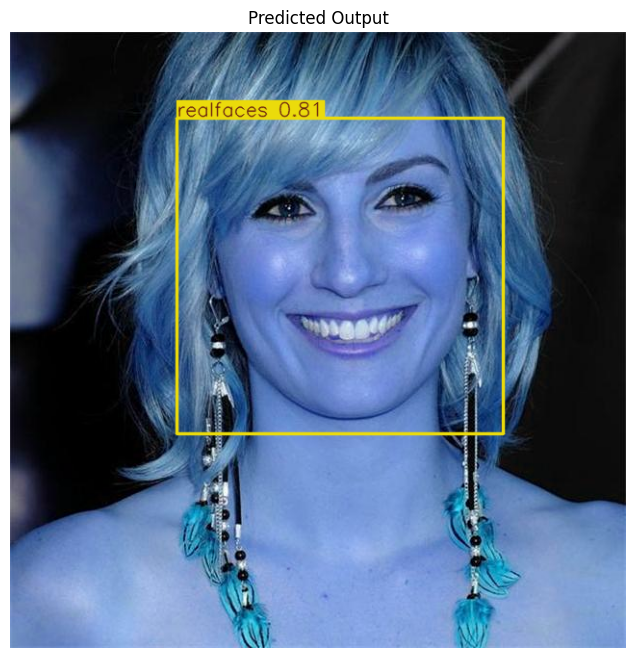

🧾 Detected objects:
 - Class: realfaces | Confidence: 0.81


In [1]:

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# === 🔧 CONFIGURATION ===

# Load the trained YOLO model
model_path = r"Y:\2024-2025\NEW DEV\OCT\TK198249-A Hybrid Deep Learning Framework for Deep fake Detection Using Temporal and Spatial Features\BACKEND\image\yolov8\train_results\yolov8_training\weights\best.pt"

# Path to the image you want to predict
image_path = r"Y:\2024-2025\NEW DEV\OCT\TK198249-A Hybrid Deep Learning Framework for Deep fake Detection Using Temporal and Spatial Features\fake.v1i.yolov8\train\images\1803151818-00000248_jpg.rf.5573c919d10b4a9b84a992be7a54750a.jpg"
# === 📦 Load model ===
model = YOLO(model_path)

# === 🔍 Run prediction ===
results = model.predict(source=image_path, conf=0.20, save=False)

# === 🖼️ Display result ===
for r in results:
    # Draw prediction on image
    img_with_boxes = r.plot()

    # Show using matplotlib
    plt.figure(figsize=(10, 8))
    plt.imshow(img_with_boxes)
    plt.axis("off")
    plt.title("Predicted Output")
    plt.show()

    # Print detected classes and confidences
    print("🧾 Detected objects:")
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        print(f" - Class: {model.names[cls]} | Confidence: {conf:.2f}")




image 1/1 Y:\2024-2025\NEW DEV\OCT\TK198249-A Hybrid Deep Learning Framework for Deep fake Detection Using Temporal and Spatial Features\fake.v1i.yolov8\train\images\-_20221117142721_png.rf.b3f3b36a73842f1285712c5a16896c5a.jpg: 640x640 1 fakefaces, 46.1ms
Speed: 2.3ms preprocess, 46.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


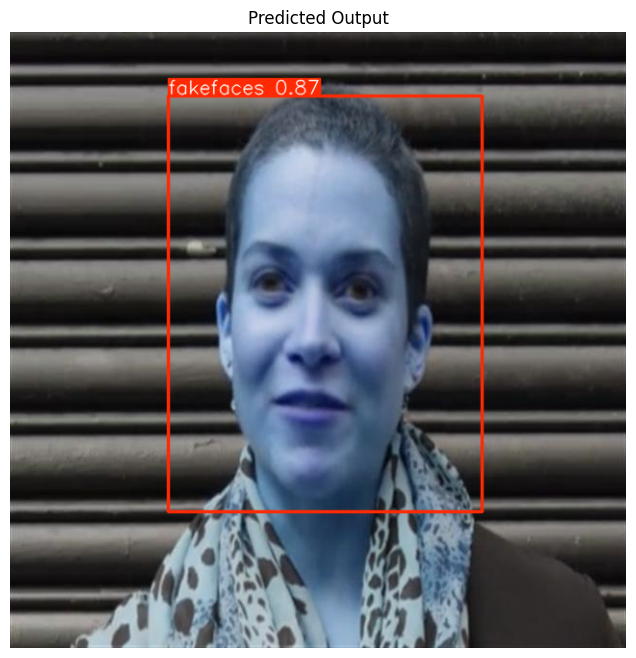

🧾 Detected objects:
 - Class: fakefaces | Confidence: 0.87


In [2]:

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# === 🔧 CONFIGURATION ===

# Load the trained YOLO model
model_path = r"Y:\2024-2025\NEW DEV\OCT\TK198249-A Hybrid Deep Learning Framework for Deep fake Detection Using Temporal and Spatial Features\BACKEND\image\yolov8\train_results\yolov8_training\weights\best.pt"

# Path to the image you want to predict
image_path = r'Y:\2024-2025\NEW DEV\OCT\TK198249-A Hybrid Deep Learning Framework for Deep fake Detection Using Temporal and Spatial Features\fake.v1i.yolov8\train\images\-_20221117142721_png.rf.b3f3b36a73842f1285712c5a16896c5a.jpg'
# === 📦 Load model ===
model = YOLO(model_path)

# === 🔍 Run prediction ===
results = model.predict(source=image_path, conf=0.20, save=False)

# === 🖼️ Display result ===
for r in results:
    # Draw prediction on image
    img_with_boxes = r.plot()

    # Show using matplotlib
    plt.figure(figsize=(10, 8))
    plt.imshow(img_with_boxes)
    plt.axis("off")
    plt.title("Predicted Output")
    plt.show()

    # Print detected classes and confidences
    print("🧾 Detected objects:")
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        print(f" - Class: {model.names[cls]} | Confidence: {conf:.2f}")

